# PPG 按运动类型分组自适应滤波协议

工程根目录统一为 `D:\python_notebook_base`。主训练流程只输出 QC 表、运动类型识别表、贝叶斯训练曲线和汇总 CSV；HR 曲线只在末尾手动重画单元格输出。


In [ ]:
# 0. 路径、依赖与统一配置
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path(r"D:\python_notebook_base")
SRC_DIR = PROJECT_ROOT / "src"
TESTDATA_DIR = PROJECT_ROOT / "testdata"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"

assert PROJECT_ROOT.exists(), f"工程根目录不存在: {PROJECT_ROOT}"
assert SRC_DIR.exists(), f"源码目录不存在: {SRC_DIR}"
assert TESTDATA_DIR.exists(), f"测试数据目录不存在: {TESTDATA_DIR}"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

try:
    import optuna
    print("optuna", optuna.__version__)
except ModuleNotFoundError:
    optuna = None
    print("未安装 optuna：会使用确定性随机搜索 fallback。")

from ppg_hr.experimental.alignment import align_ppg_to_ref_hr
from ppg_hr.experimental.batch_pairing import discover_sample_pairs_with_unpaired
from ppg_hr.experimental.preprocess_protocol import load_and_preprocess_protocol, resample_protocol_dataset
from ppg_hr.experimental.qc import quality_filter_sample
from ppg_hr.experimental.protocol_outputs import plot_rest_alignment_diagnostics_by_motion_type
from ppg_hr.experimental.run_batch_protocol import (
    build_output_run_name,
    redraw_best_param_hr_curves,
    run_batch_adaptive_protocol,
    safe_prepare_output_dir,
)
from ppg_hr.experimental.segmentation import detect_activity_segments
from ppg_hr.params import ProtocolSearchParams

RANDOM_STATE = 42
FS_ORIGIN = 100
CLEAN_OUTPUTS = False
OPTIMIZATION_OBJECTIVE = "accuracy"  # 可选 "accuracy" 或 "aae"
DATA_SPLIT_MODE = "all_train"  # 可选 "split"、"all_train" 或 "leave_one_group_out"
VAL_GROUPS_PER_TYPE = 1
TEST_GROUPS_PER_TYPE = 1
DELAY_ESTIMATION_MODE = "envelope"  # optional "envelope" or "direct"; default keeps old envelope delay logic
ACTIVE_TARGET_SCOPES = ["motion_only", "motion_recovery"]
ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "CF2", "HF2_CF2", "HF2_ACC3"]
ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms"]
CASCADE_TRAIN_BUDGETS = {scheme: {"n_trials": 1, "n_repeats": 1} for scheme in ACTIVE_CASCADE_SCHEMES}

def make_unique_output_dir(target_scopes, cascade_schemes, adaptive_filters, objective_mode, split_mode):
    base_name = build_output_run_name(target_scopes, cascade_schemes, adaptive_filters, objective_mode, split_mode)
    run_name = base_name
    run_dir = OUTPUT_ROOT / run_name
    if not CLEAN_OUTPUTS:
        idx = 1
        while run_dir.exists() and any(run_dir.iterdir()):
            run_name = f"{base_name}__run{idx:02d}"
            run_dir = OUTPUT_ROOT / run_name
            idx += 1
    run_dir = safe_prepare_output_dir(project_root=PROJECT_ROOT, output_dir=run_dir, clean_outputs=CLEAN_OUTPUTS)
    return run_name, run_dir

OUTPUT_RUN_NAME, RUN_OUTPUT_DIR = make_unique_output_dir(
    ACTIVE_TARGET_SCOPES,
    ACTIVE_CASCADE_SCHEMES,
    ACTIVE_ADAPTIVE_FILTERS,
    OPTIMIZATION_OBJECTIVE,
    DATA_SPLIT_MODE,
)
print("PROJECT_ROOT:", PROJECT_ROOT)
print("SRC_DIR:", SRC_DIR)
print("TESTDATA_DIR:", TESTDATA_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("OUTPUT_RUN_NAME:", OUTPUT_RUN_NAME)
print("RUN_OUTPUT_DIR:", RUN_OUTPUT_DIR)


## 1. 数据配对、运动类型识别与 QC

扫描 `testdata` 中的 `multi_<运动类型拼音+数字编号>.csv` 和对应 `_ref.csv`。未配对文件不进入 QC 和训练。


In [ ]:
discovery = discover_sample_pairs_with_unpaired(TESTDATA_DIR)
pairs_df = pd.DataFrame([
    {
        "group_id": p.motion_id,
        "motion_type": p.motion_type,
        "motion_index": p.motion_index,
        "data_file": p.sensor_csv.name,
        "ref_file": p.ref_csv.name,
    }
    for p in discovery.pairs
])
unpaired_df = pd.DataFrame([
    {"file_name": u.file_name, "file_path": str(u.file_path), "reason": u.reason}
    for u in discovery.unpaired
])

qc_rows = []
good_pairs = []
bad_pairs = []
for pair in discovery.pairs:
    qc = quality_filter_sample(pair.sensor_csv, fs=FS_ORIGIN, group_id=pair.motion_id, motion_type=pair.motion_type, ref_csv=pair.ref_csv)
    qc_rows.append(qc.to_dict())
    if qc.is_good:
        good_pairs.append(pair)
    else:
        bad_pairs.append(pair)
qc_df = pd.DataFrame(qc_rows)

print("配对总数:", len(discovery.pairs))
print("未配对文件数量:", len(discovery.unpaired))
print("好样本数量:", len(good_pairs))
print("坏样本数量:", len(bad_pairs))
print("当前识别到的运动类型列表:", sorted(pairs_df["motion_type"].unique()) if not pairs_df.empty else [])
if not pairs_df.empty:
    display(pairs_df.groupby("motion_type")[["group_id", "data_file"]].agg(list).reset_index())
display(pairs_df)
display(unpaired_df)
display(qc_df)


## 2. 预处理、分段与对齐预览

用第一组好样本验证预处理、运动分段和 PPG-HR 对齐。


In [ ]:
if good_pairs:
    pair = good_pairs[0]
    ds = load_and_preprocess_protocol(pair.sensor_csv, pair.ref_csv, fs_origin=FS_ORIGIN)
    ds = resample_protocol_dataset(ds, fs_target=100)
    seg = detect_activity_segments(ds.accx, ds.accy, ds.accz, ds.fs, TW=8)
    if not seg.is_valid:
        print(f"分段失败: {pair.stem}: {seg.reason}")
    else:
        aligned = align_ppg_to_ref_hr(ds, seg, TW=8, fs_target=ds.fs)
        display(pd.DataFrame([{
            "sample": pair.stem,
            "motion_type": pair.motion_type,
            "fs": ds.fs,
            "motion_start_s": aligned.segment_info.motion_start_s,
            "motion_end_s": aligned.segment_info.motion_end_s,
            "best_tdelay_s": aligned.alignment_info.best_tdelay_s,
            "num_windows": aligned.alignment_info.num_windows,
            "rest_windows": len(aligned.rest_indices),
            "motion_windows": len(aligned.motion_indices),
            "recovery_windows": len(aligned.recovery_indices),
        }]))
else:
    print("没有 QC 通过的样本。")


## 3. 全局 Tdelay 静息段对齐诊断图（TW=10）

Plot rest-segment Reference HR and PPG FFT HR by motion type. These figures are diagnostics only and do not affect training or Tdelay selection; default Alignment_TW is 8 s.


alignment_diagnostics: {'bobi': WindowsPath('D:/python_notebook_base/outputs/motion_only-motion_recovery__ACC3-HF2-CF2-HF2_CF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__all_train/alignment_diagnostics/bobi_rest_alignment_TW4.png'), 'fuwo': WindowsPath('D:/python_notebook_base/outputs/motion_only-motion_recovery__ACC3-HF2-CF2-HF2_CF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__all_train/alignment_diagnostics/fuwo_rest_alignment_TW4.png'), 'kaihe': WindowsPath('D:/python_notebook_base/outputs/motion_only-motion_recovery__ACC3-HF2-CF2-HF2_CF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__all_train/alignment_diagnostics/kaihe_rest_alignment_TW4.png'), 'tiaosheng': WindowsPath('D:/python_notebook_base/outputs/motion_only-motion_recovery__ACC3-HF2-CF2-HF2_CF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__all_train/alignment_diagnostics/tiaosheng_rest_alignment_TW4.png'), 'wanju': WindowsPath('D:/python_notebook_base/outputs/motion_only-motion_recovery__ACC3-HF2-CF2-HF2_CF2-HF2_ACC3__lms-volterra-rff_l

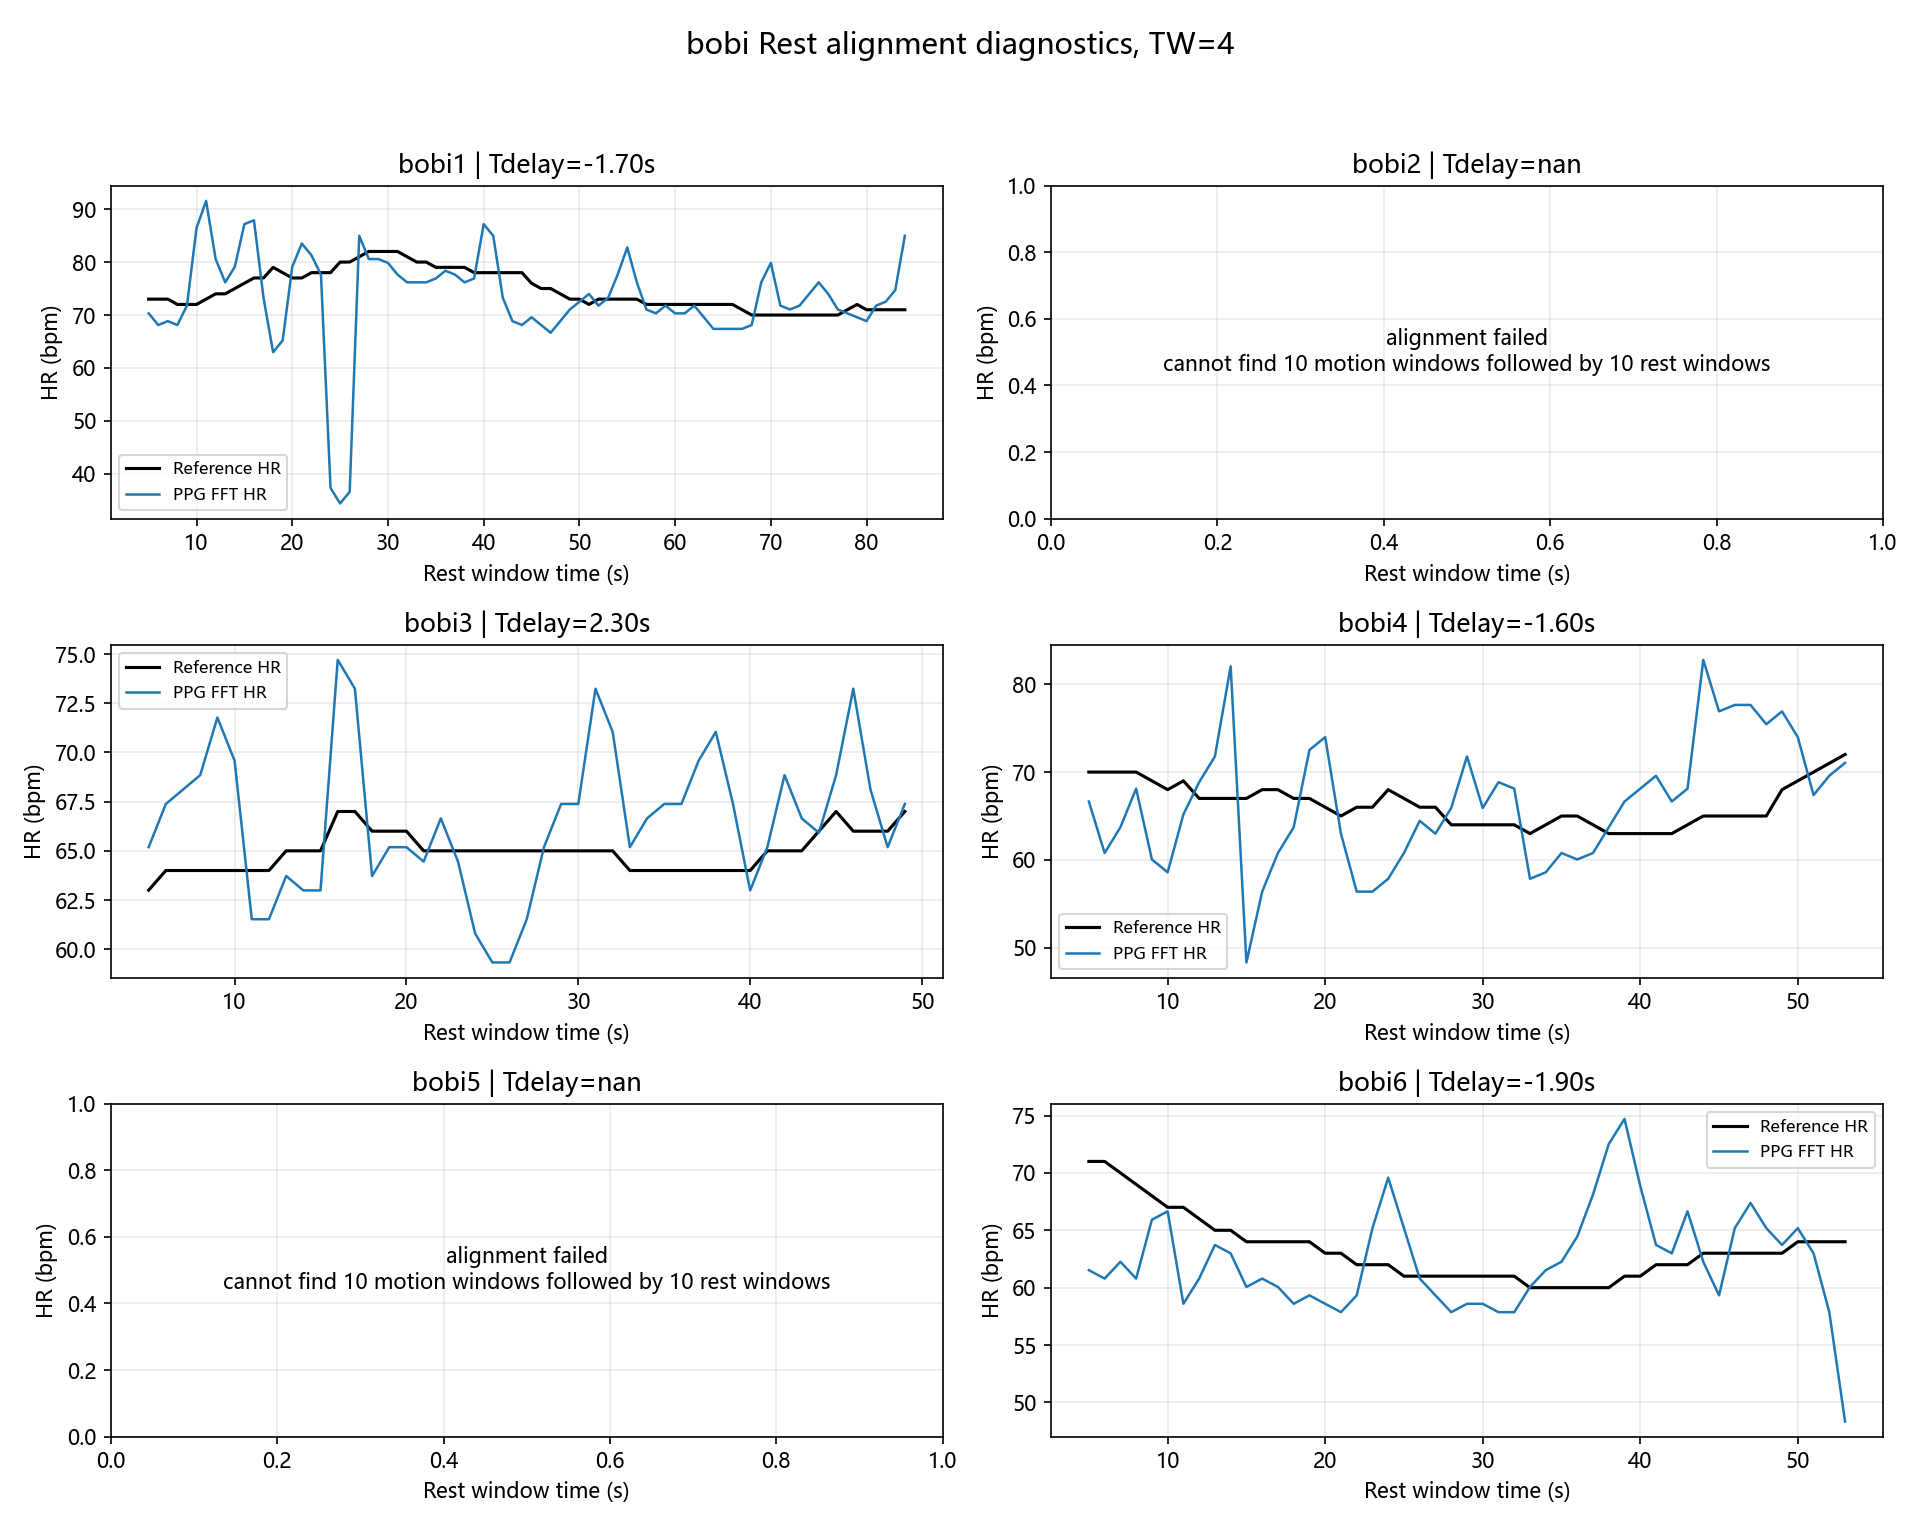

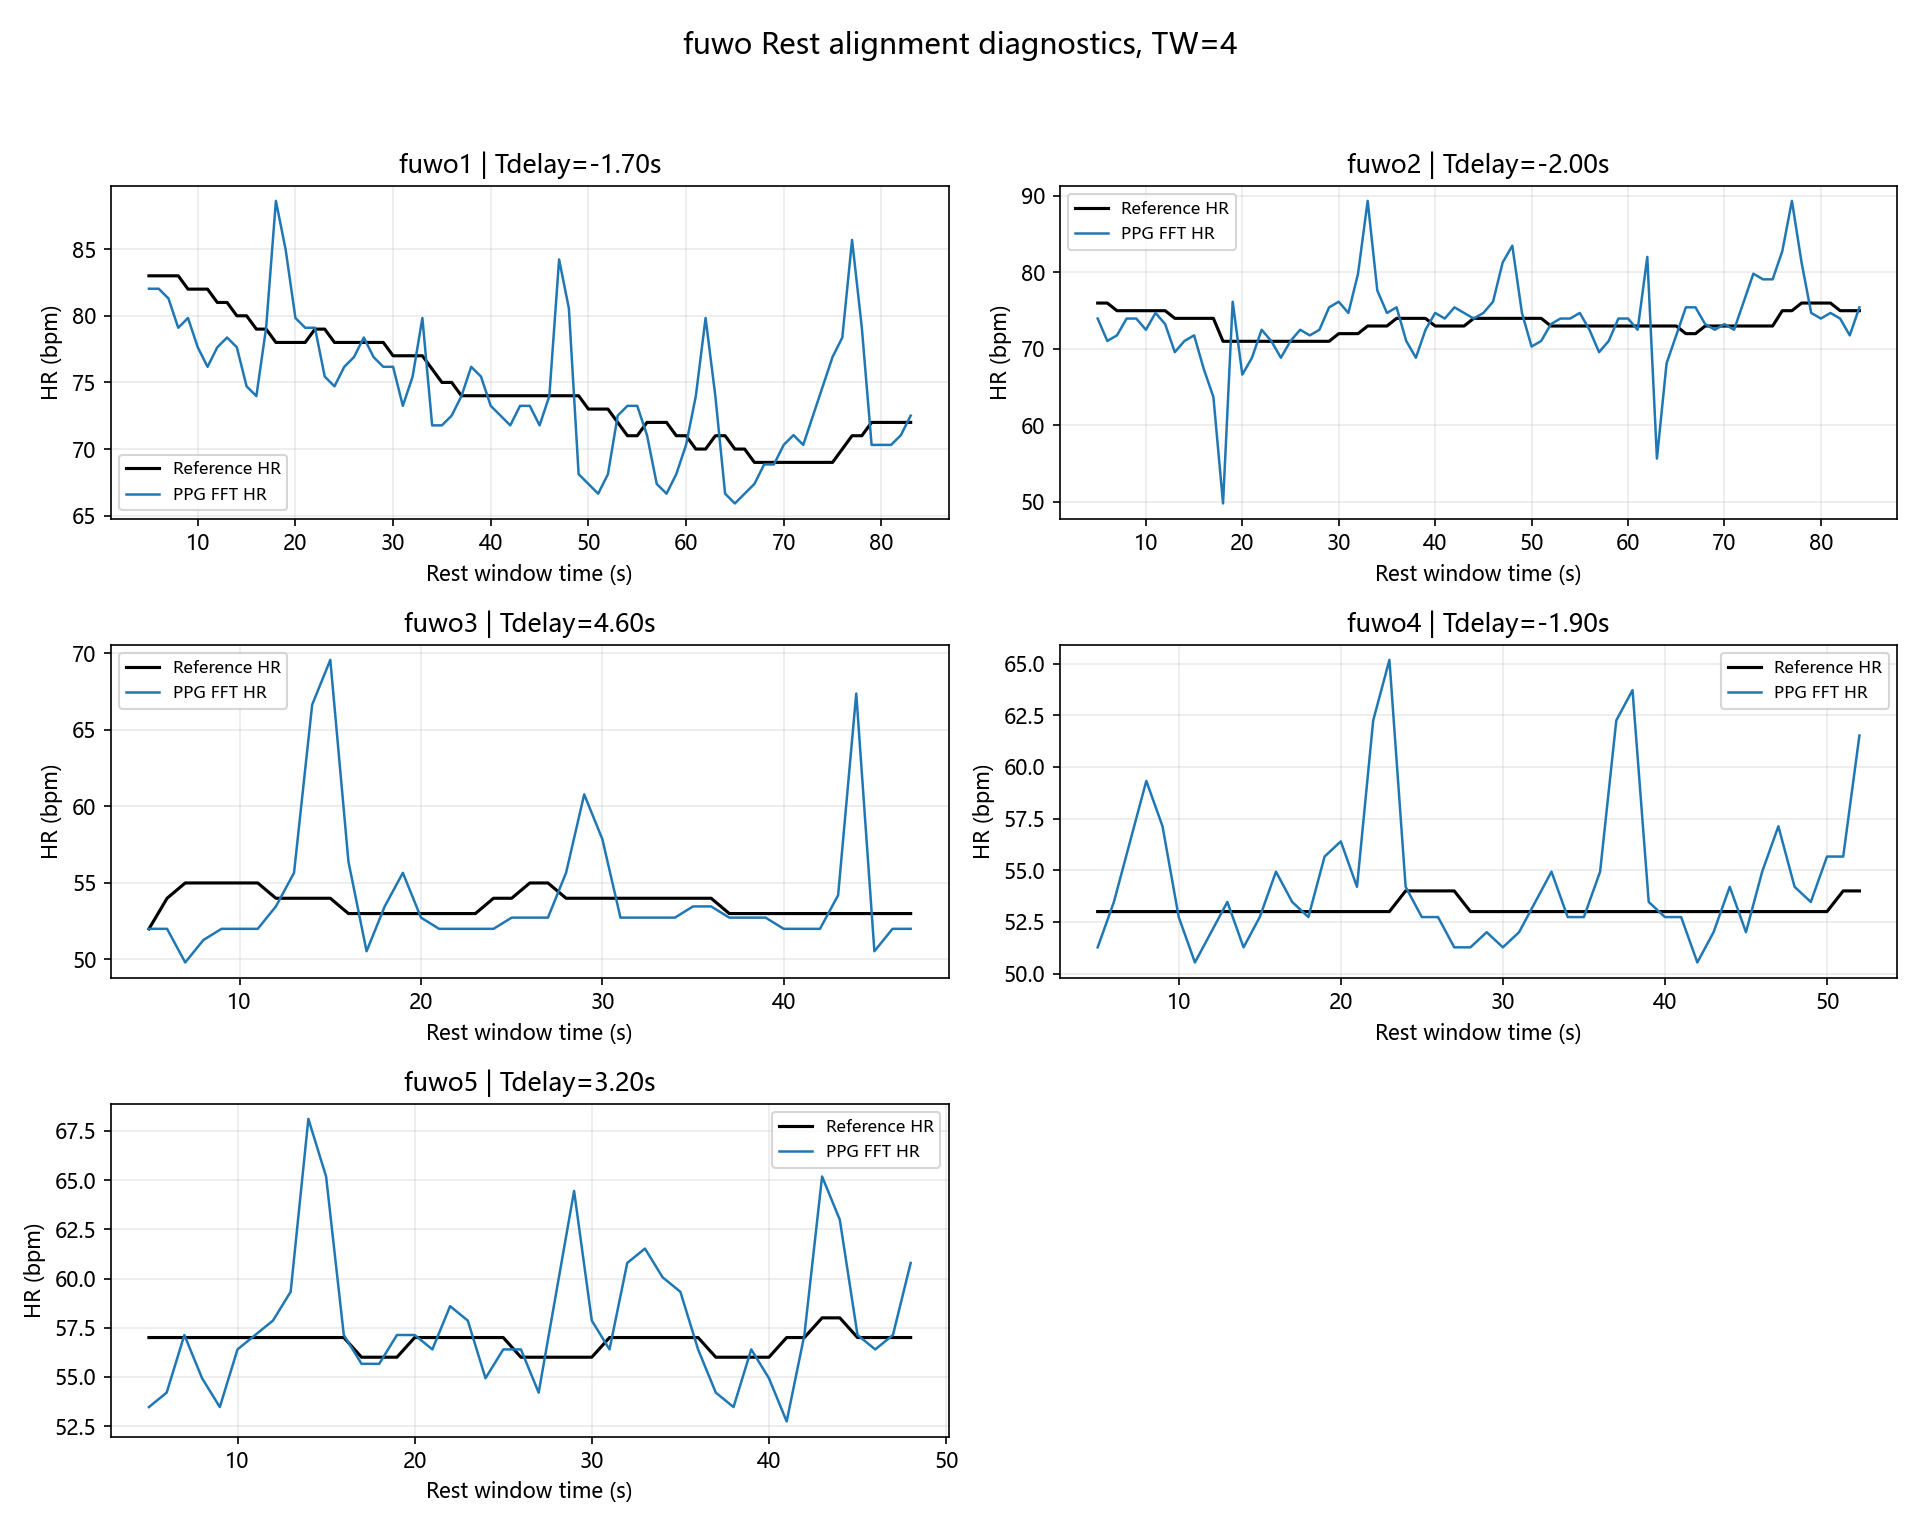

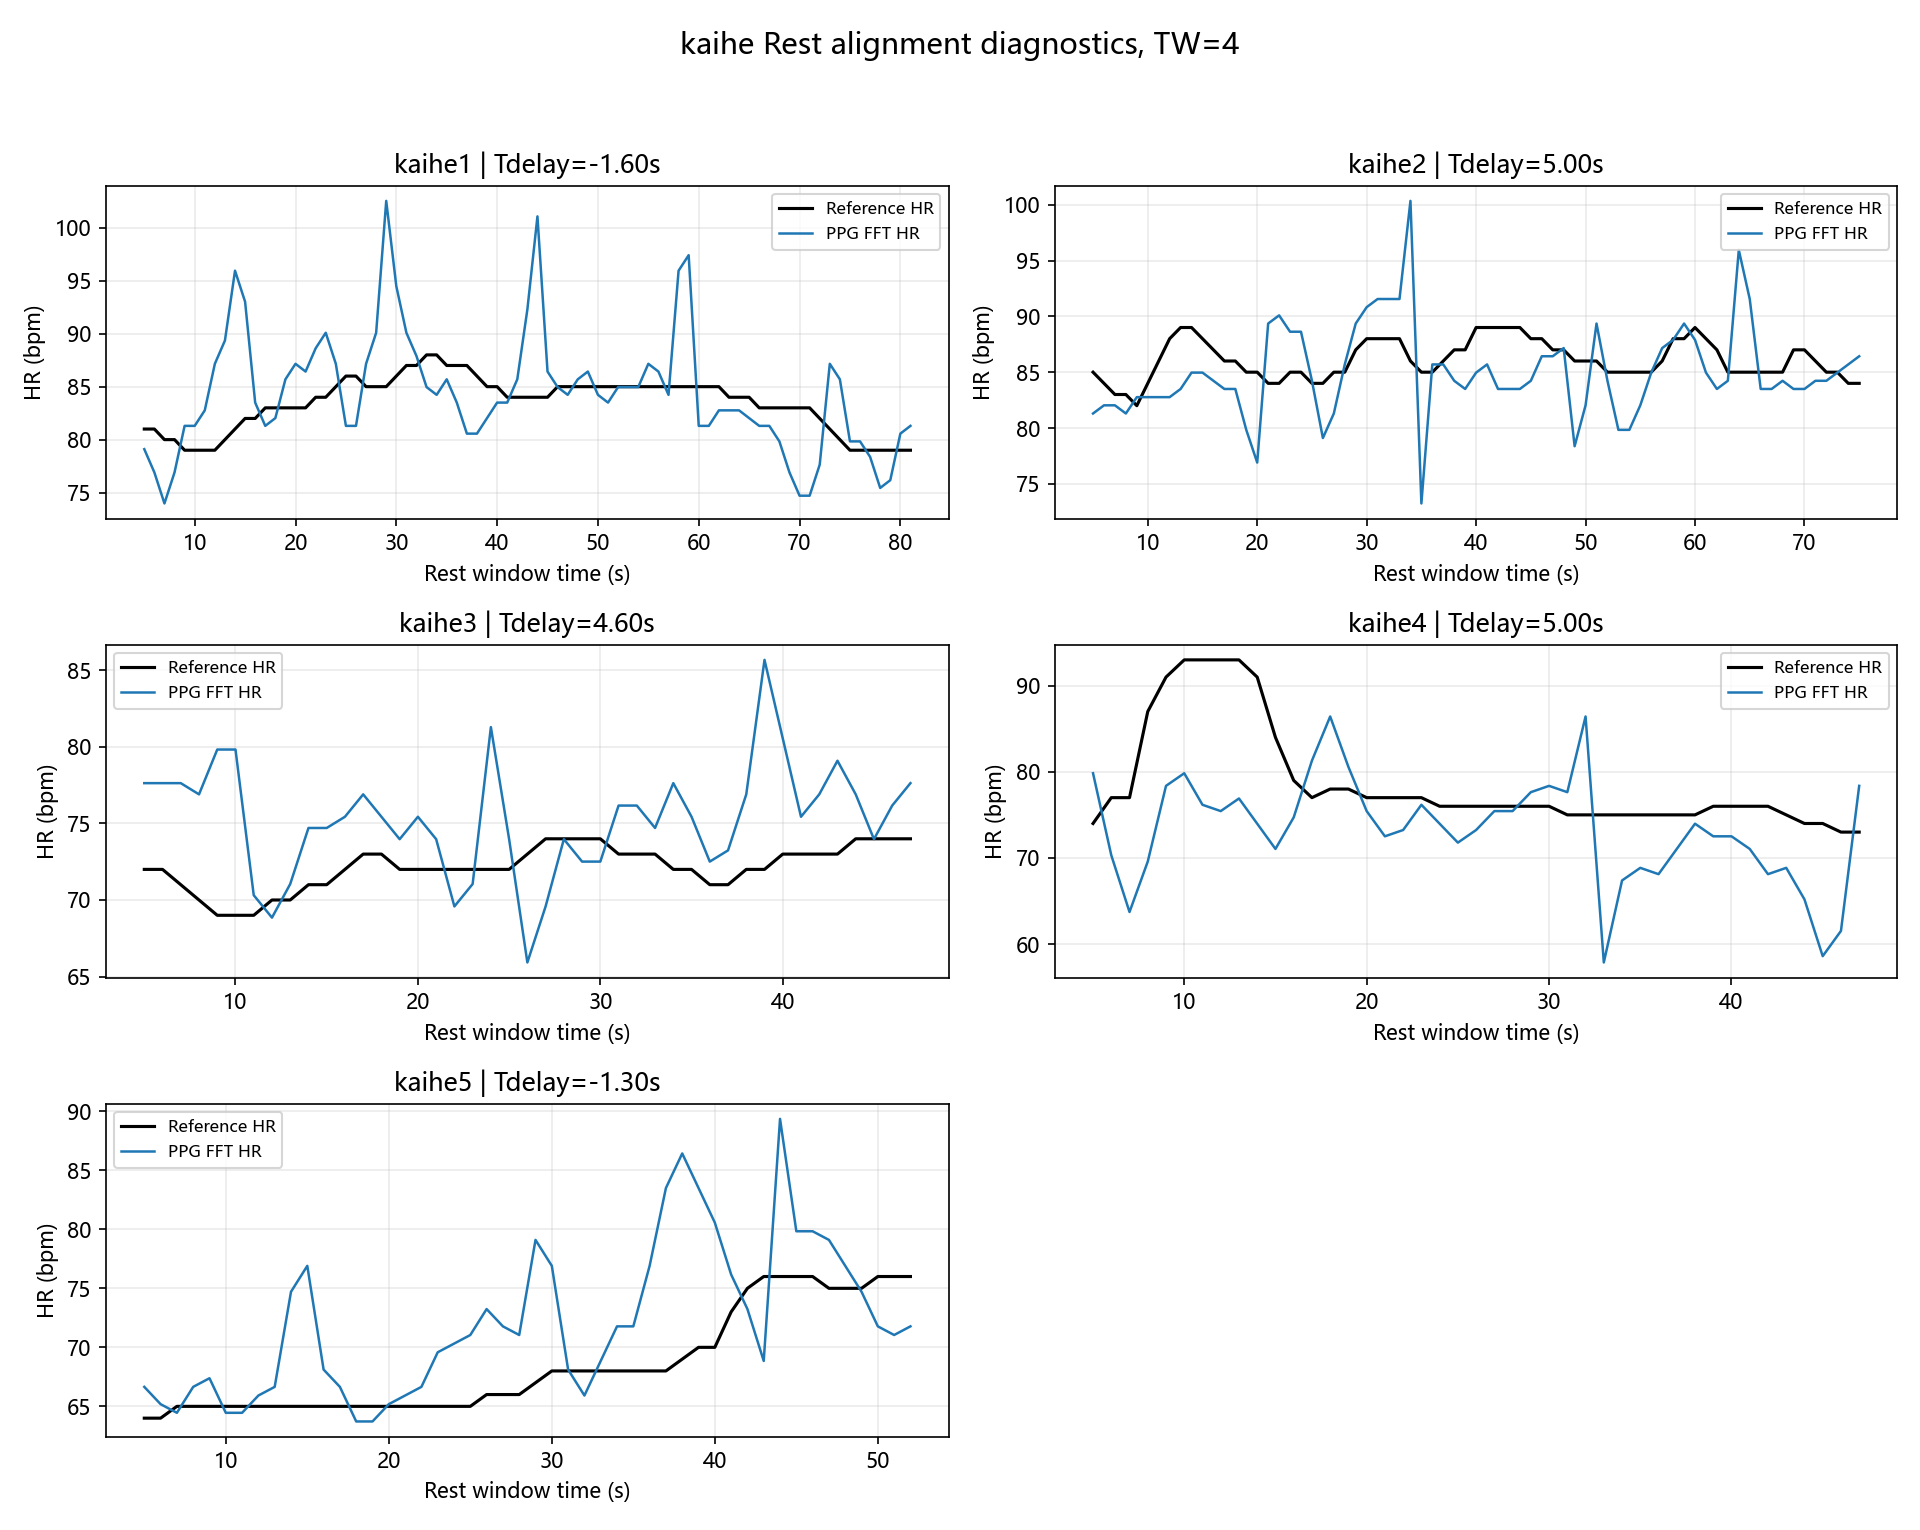

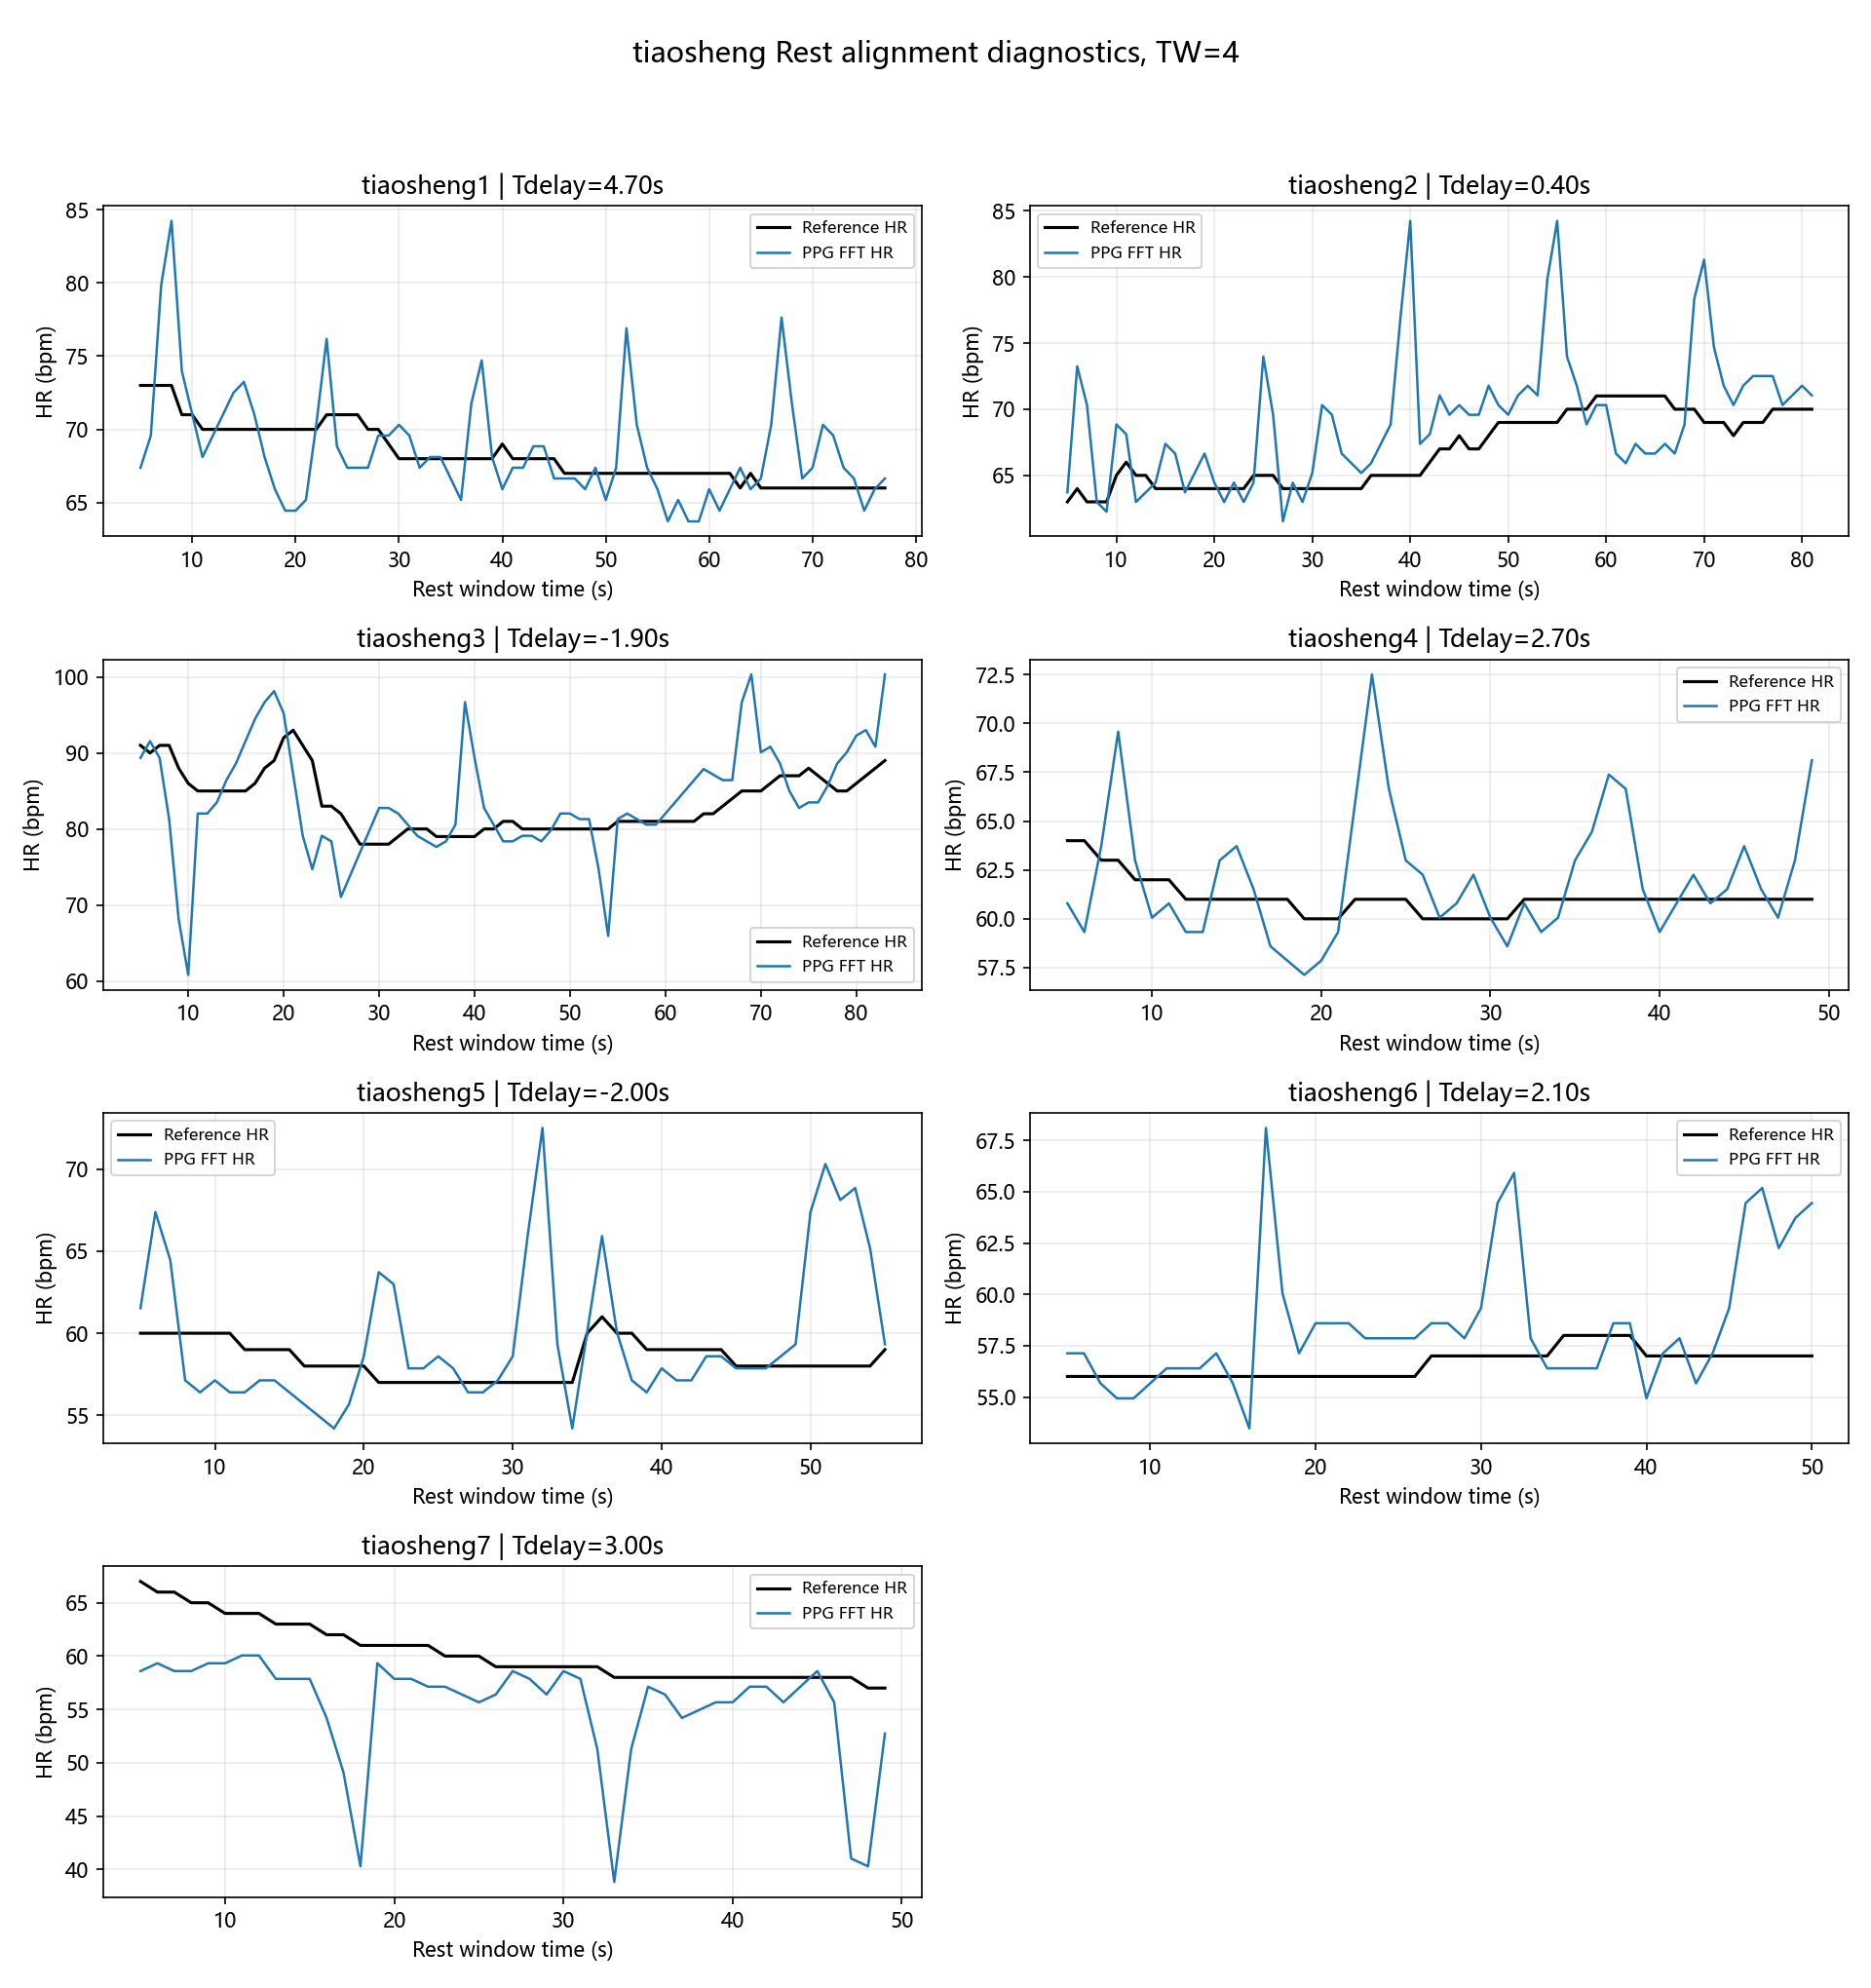

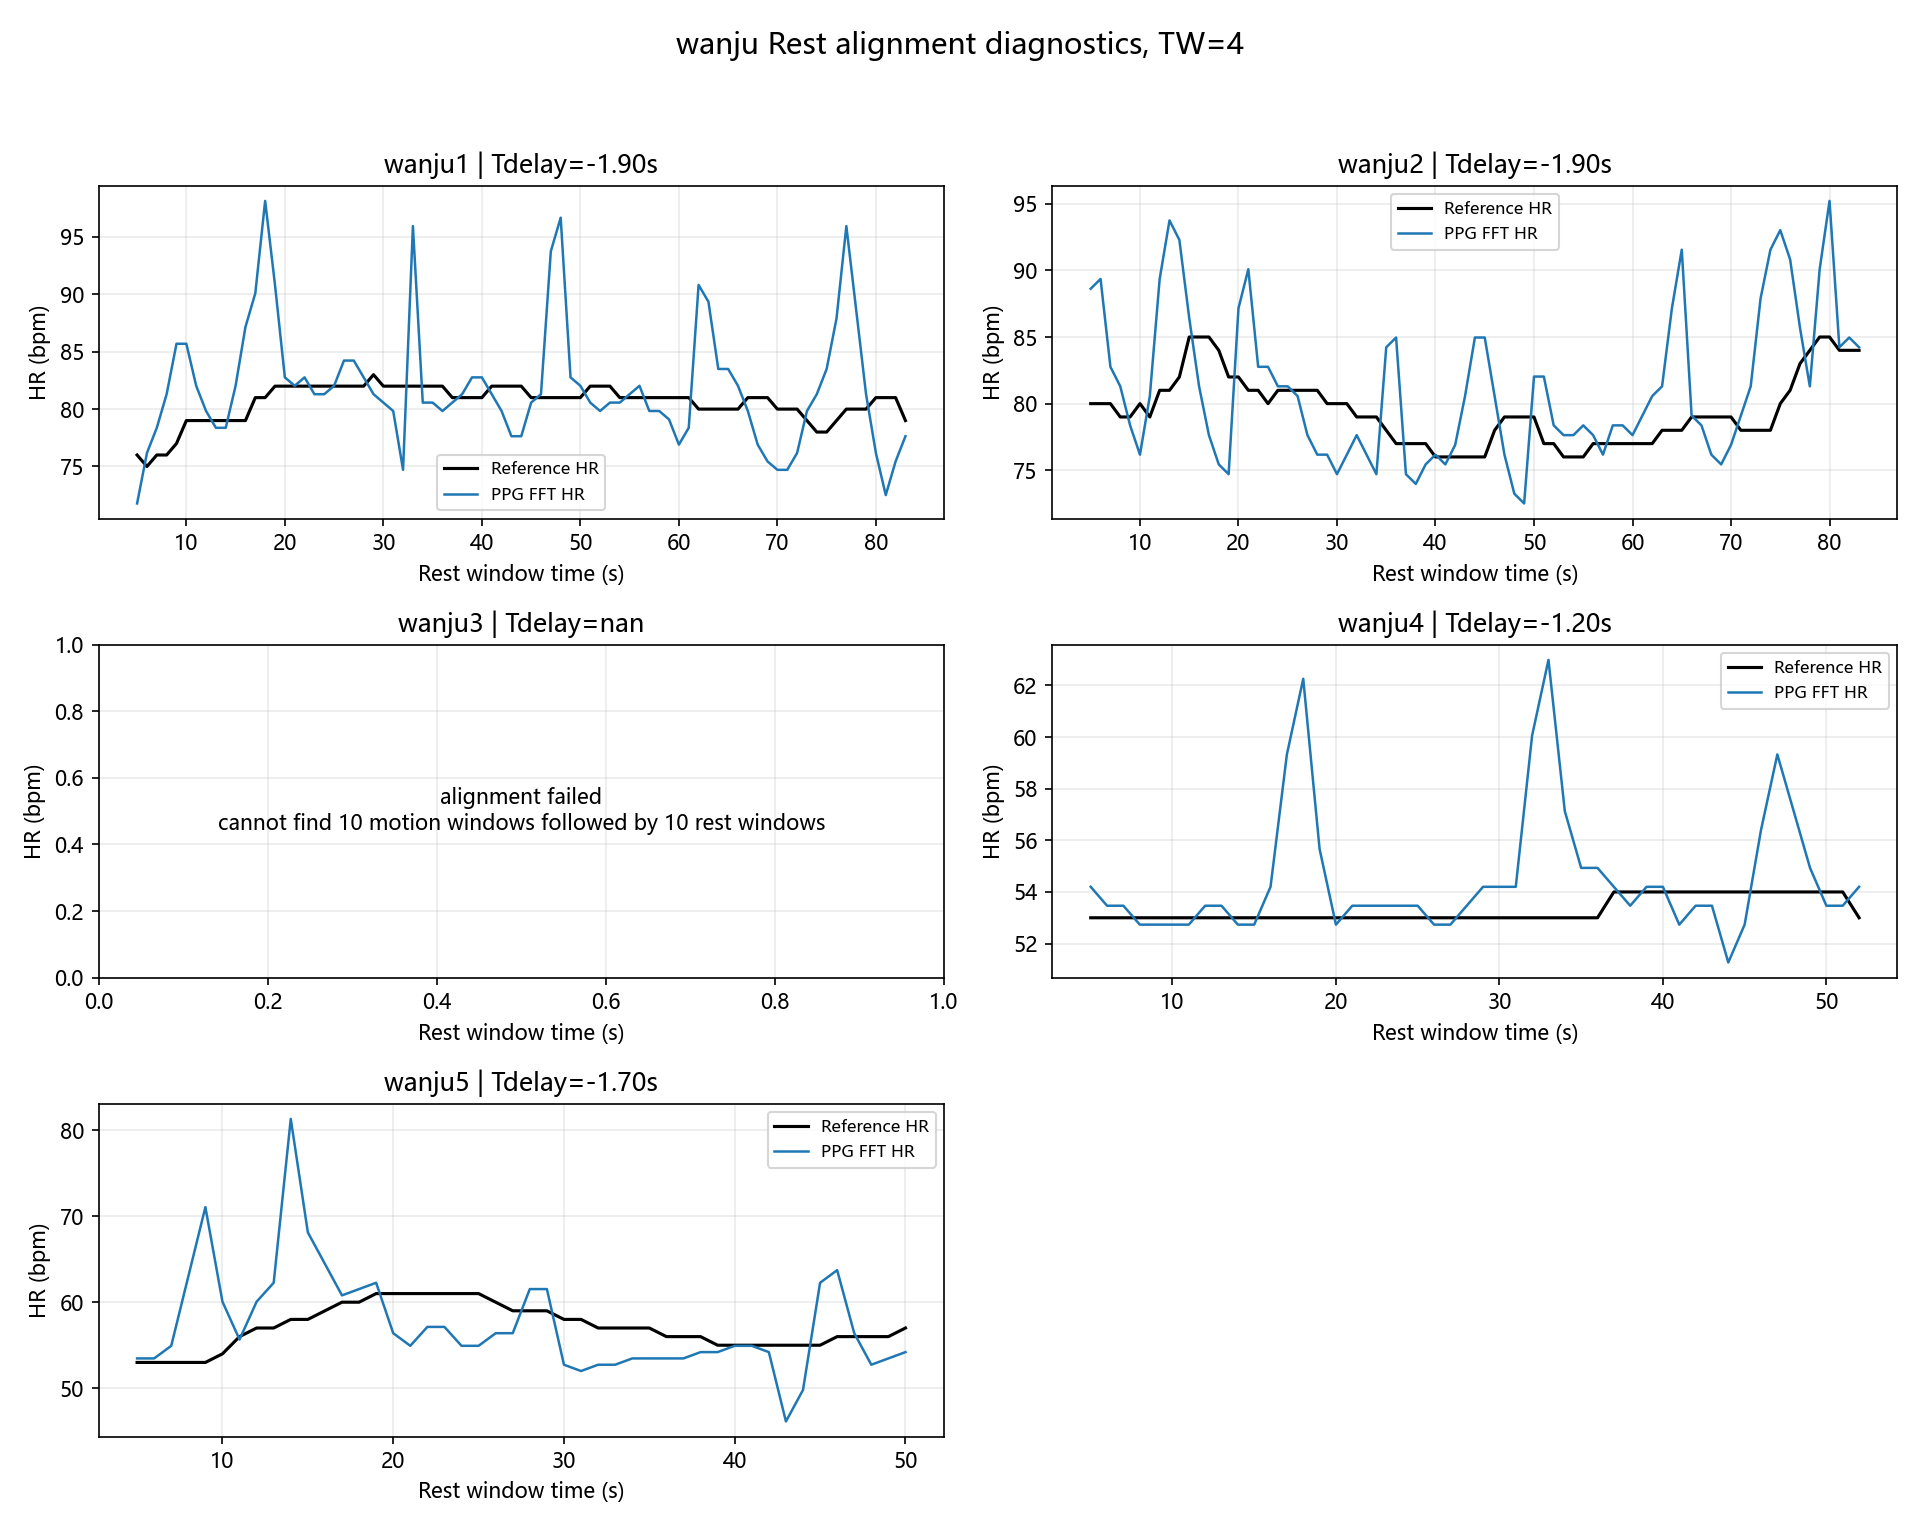

In [10]:
ALIGNMENT_DIAGNOSTIC_DIR = RUN_OUTPUT_DIR / "alignment_diagnostics"

alignment_diagnostic_datasets = {}
for pair in good_pairs:
    try:
        alignment_diagnostic_datasets[pair.motion_id] = load_and_preprocess_protocol(
            pair.sensor_csv,
            pair.ref_csv,
            fs_origin=FS_ORIGIN,
        )
    except Exception as exc:
        print(f"alignment diagnostic preprocessing failed: {pair.motion_id}: {exc}")

alignment_diagnostic_paths = plot_rest_alignment_diagnostics_by_motion_type(
    pairs=good_pairs,
    datasets=alignment_diagnostic_datasets,
    output_dir=ALIGNMENT_DIAGNOSTIC_DIR,
    fs_target=100,
    TW=4,
)
print("alignment_diagnostics:", alignment_diagnostic_paths)
for image_path in alignment_diagnostic_paths.values():
    display(Image(filename=str(image_path)))


## 4. 训练辅助函数

`run_training_cell` builds a unique output directory and calls the batch runner with the active scopes, cascade schemes, filters, objective, split mode and delay-estimation mode.


In [ ]:
def make_budgets(schemes, n_trials=1, n_repeats=1):
    return {scheme: {"n_trials": int(n_trials), "n_repeats": int(n_repeats)} for scheme in schemes}

PROGRESS_EVERY_N_TRIALS = 10

def notebook_progress(info):
    stage = info.get("stage", "")
    if stage == "optimization":
        trial_idx = int(info.get("trial_idx") or 0)
        trial_total = int(info.get("trial_total") or 0)
        if trial_idx == 1 or trial_idx == trial_total or trial_idx % PROGRESS_EVERY_N_TRIALS == 0:
            print(
                f"motion_type {info.get('motion_type')} | "
                f"mode {info.get('mode_idx')}/{info.get('mode_total')} | "
                f"{info.get('target_scope_value')} / {info.get('cascade_scheme')} / {info.get('adaptive_filter')} | "
                f"repeat {info.get('repeat_idx')}/{info.get('repeat_total')} | "
                f"trial {trial_idx}/{trial_total} | "
                f"AAE {info.get('aae_bpm')} | accuracy {info.get('accuracy_pct')} | "
                f"objective_mode {info.get('objective_mode')} | objective_value {info.get('objective_value')}"
            )
    elif stage == "optimization_mode":
        print(
            f"enter mode {info.get('mode_idx')}/{info.get('mode_total')}: "
            f"{info.get('motion_type')} / {info.get('target_scope_value')} / "
            f"{info.get('cascade_scheme')} / {info.get('adaptive_filter')}"
        )
    elif stage in {"qc", "preprocess"}:
        print(f"{stage} {info.get('current')}/{info.get('total')}: {info.get('sample')}")

def run_training_cell(
    *,
    active_target_scopes,
    active_cascade_schemes,
    active_adaptive_filters,
    cascade_train_budgets,
    optimization_objective,
    data_split_mode,
    val_groups_per_type=1,
    test_groups_per_type=1,
    delay_estimation_mode=DELAY_ESTIMATION_MODE,
):
    output_run_name, run_output_dir = make_unique_output_dir(
        active_target_scopes,
        active_cascade_schemes,
        active_adaptive_filters,
        optimization_objective,
        data_split_mode,
    )
    print("OUTPUT_RUN_NAME:", output_run_name)
    print("RUN_OUTPUT_DIR:", run_output_dir)
    result = run_batch_adaptive_protocol(
        input_dir=TESTDATA_DIR,
        output_root=run_output_dir,
        max_iterations=1,
        num_repeats=1,
        random_state=RANDOM_STATE,
        num_seed_points=1,
        fs_origin=FS_ORIGIN,
        n_jobs=1,
        debug_mode=True,
        search_space=ProtocolSearchParams(),
        target_scopes=active_target_scopes,
        cascade_schemes=active_cascade_schemes,
        adaptive_filters=active_adaptive_filters,
        objective_mode=optimization_objective,
        data_split_mode=data_split_mode,
        delay_estimation_mode=delay_estimation_mode,
        val_groups_per_type=val_groups_per_type,
        test_groups_per_type=test_groups_per_type,
        cascade_train_budgets=cascade_train_budgets,
        project_root=PROJECT_ROOT,
        clean_outputs=CLEAN_OUTPUTS,
        verbose=True,
        on_log=print,
        progress_callback=notebook_progress,
    )
    print("batch_summary:", result.batch_summary_csv)
    print("final_summary:", result.final_summary_tables)
    return result


## 5. 训练单元格 1：all_train 全样本拟合上限检查

All good samples are used as train/test to inspect the upper-bound fitting behavior.


In [ ]:
ACTIVE_TARGET_SCOPES = ["motion_only", "motion_recovery"]
ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "CF2", "HF2_CF2", "HF2_ACC3"]
ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms"]
CASCADE_TRAIN_BUDGETS = {
    "ACC3": {"n_trials": 200, "n_repeats": 2},
    "HF2": {"n_trials": 500, "n_repeats": 3},
    "CF2": {"n_trials": 200, "n_repeats": 2},
    "HF2_CF2": {"n_trials": 500, "n_repeats": 3},
    "HF2_ACC3": {"n_trials": 500, "n_repeats": 3},
}
DELAY_ESTIMATION_MODE = "envelope"
OPTIMIZATION_OBJECTIVE = "accuracy"
DATA_SPLIT_MODE = "all_train"
VAL_GROUPS_PER_TYPE = 1
TEST_GROUPS_PER_TYPE = 1

result_all_train = run_training_cell(
    active_target_scopes=ACTIVE_TARGET_SCOPES,
    active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
    active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
    cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
    optimization_objective=OPTIMIZATION_OBJECTIVE,
    data_split_mode=DATA_SPLIT_MODE,
    val_groups_per_type=VAL_GROUPS_PER_TYPE,
    test_groups_per_type=TEST_GROUPS_PER_TYPE,
)


## 6. 训练单元格 2：leave-one-group-out 正式泛化评估

Formal generalization evaluation: each group is held out once as test, while the remaining groups are used as train and val is disabled.


In [ ]:
ACTIVE_TARGET_SCOPES = ["motion_only", "motion_recovery"]
ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "CF2", "HF2_CF2", "HF2_ACC3"]
ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms"]
# CASCADE_TRAIN_BUDGETS = make_budgets(ACTIVE_CASCADE_SCHEMES, n_trials=1, n_repeats=1)
CASCADE_TRAIN_BUDGETS = {
    "ACC3": {"n_trials": 200, "n_repeats": 2},
    "HF2": {"n_trials": 500, "n_repeats": 3},
    "CF2": {"n_trials": 200, "n_repeats": 2},
    "HF2_CF2": {"n_trials": 500, "n_repeats": 3},
    "HF2_ACC3": {"n_trials": 500, "n_repeats": 3},
}
DELAY_ESTIMATION_MODE = "envelope"
OPTIMIZATION_OBJECTIVE = "accuracy"
DATA_SPLIT_MODE = "leave_one_group_out"

result_leave_one_group_out = run_training_cell(
    active_target_scopes=ACTIVE_TARGET_SCOPES,
    active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
    active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
    cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
    optimization_objective=OPTIMIZATION_OBJECTIVE,
    data_split_mode=DATA_SPLIT_MODE,
)


## 7. 训练单元格 3：全量 63 模式跑通测试


In [ ]:
RUN_FULL_63_MODE_TEST = False

if RUN_FULL_63_MODE_TEST:
    ACTIVE_TARGET_SCOPES = ["motion_only", "motion_recovery", "motion_post10"]
    ACTIVE_CASCADE_SCHEMES = ["ACC3", "HF2", "CF2", "HF2_CF2", "CF2_HF2", "ACC3_HF2", "HF2_ACC3"]
    ACTIVE_ADAPTIVE_FILTERS = ["lms", "volterra", "rff_lms"]
    CASCADE_TRAIN_BUDGETS = make_budgets(ACTIVE_CASCADE_SCHEMES, n_trials=1, n_repeats=1)
    OPTIMIZATION_OBJECTIVE = "accuracy"
    DATA_SPLIT_MODE = "split"
    VAL_GROUPS_PER_TYPE = 1
    TEST_GROUPS_PER_TYPE = 1
    result_full_63 = run_training_cell(
        active_target_scopes=ACTIVE_TARGET_SCOPES,
        active_cascade_schemes=ACTIVE_CASCADE_SCHEMES,
        active_adaptive_filters=ACTIVE_ADAPTIVE_FILTERS,
        cascade_train_budgets=CASCADE_TRAIN_BUDGETS,
        optimization_objective=OPTIMIZATION_OBJECTIVE,
        data_split_mode=DATA_SPLIT_MODE,
        val_groups_per_type=VAL_GROUPS_PER_TYPE,
        test_groups_per_type=TEST_GROUPS_PER_TYPE,
    )
else:
    print("RUN_FULL_63_MODE_TEST=False，本单元格不会启动全量跑通测试。")


## 8. 输出表检查


In [ ]:
RESULT_TO_CHECK = globals().get("result_leave_one_group_out", globals().get("result_all_train", globals().get("result_split", None)))
if RESULT_TO_CHECK is None:
    print("还没有训练结果对象。")
else:
    print("output_root:", RESULT_TO_CHECK.output_root)
    print("qc_tables:", RESULT_TO_CHECK.qc_tables)
    print("batch_summary:", RESULT_TO_CHECK.batch_summary_csv)
    if RESULT_TO_CHECK.batch_summary_csv and Path(RESULT_TO_CHECK.batch_summary_csv).exists():
        display(pd.read_csv(RESULT_TO_CHECK.batch_summary_csv))
    for motion_type, motion_dir in RESULT_TO_CHECK.motion_type_dirs.items():
        print("motion_type:", motion_type, motion_dir)
        for name in ["split_files.csv", "fold_split_files.csv", "mode_summary_aae.csv", "mode_summary_accuracy.csv", "fold_summary_aae.csv", "bayes_curve_data.csv"]:
            path = motion_dir / name
            print(name, path.exists(), path)
            if path.exists():
                display(pd.read_csv(path).head())
        curve_png = motion_dir / "bayes_curve.png"
        if curve_png.exists():
            display(Image(filename=str(curve_png)))
    for key, path in RESULT_TO_CHECK.final_summary_tables.items():
        print(key, path)
        if Path(path).exists():
            display(pd.read_csv(path).head())


## 9. 手动重画最佳参数 HR 曲线


In [ ]:
RUN_MANUAL_REDRAW = True

SENSOR_CSV_PATH = TESTDATA_DIR / "multi_tiaosheng1.csv"
REF_CSV_PATH = TESTDATA_DIR / "multi_tiaosheng1_ref.csv"
TARGET_SCOPE = "motion_only"
CASCADE_SCHEME = "ACC3"
ADAPTIVE_FILTER = "lms"
BEST_PARAM_CSV_PATH = "D:/python_notebook_base/outputs/motion_only-motion_recovery-motion_post10__ACC3-HF2-CF2-HF2_CF2-CF2_HF2-ACC3_HF2-HF2_ACC3__lms-volterra-rff_lms__accuracy__split__run01/motion_types/tiaosheng/best_params_lms.csv"
OUTPUT_DIR = OUTPUT_ROOT / "manual_redraw"

if RUN_MANUAL_REDRAW:
    manual_paths = redraw_best_param_hr_curves(
        sensor_csv_path=SENSOR_CSV_PATH,
        ref_csv_path=REF_CSV_PATH,
        target_scope=TARGET_SCOPE,
        cascade_scheme=CASCADE_SCHEME,
        adaptive_filter=ADAPTIVE_FILTER,
        best_param_csv_path=BEST_PARAM_CSV_PATH,
        output_dir=OUTPUT_DIR,
        fs_origin=FS_ORIGIN,
    )
    print(manual_paths)
    for image_path in manual_paths.values():
        display(Image(filename=str(image_path)))
else:
    print("RUN_MANUAL_REDRAW=False。设置好 BEST_PARAM_CSV_PATH 后改为 True 即可重画 HR 曲线。")
